In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Update this path to match where your CSV is stored in Google Drive
file_path = "/content/drive/MyDrive/CIS Teaching Demo 2026/[Dataset] predictive_maintenance.csv"

df = pd.read_csv(file_path)

# Preview the data
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 10)


,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Target,Failure_Type
0,3237,M18096,M,300.8,309.4,1342,62.4,113,1,Heat Dissipation Failure
1,3761,L50940,L,302.3,310.9,1377,46.8,166,1,Heat Dissipation Failure
2,3788,L50967,L,302.3,310.8,1377,47.3,22,1,Heat Dissipation Failure
3,3794,L50973,L,302.3,310.9,1379,49.3,34,1,Heat Dissipation Failure
4,3807,M18666,M,302.3,310.9,1360,44.0,67,1,Heat Dissipation Failure


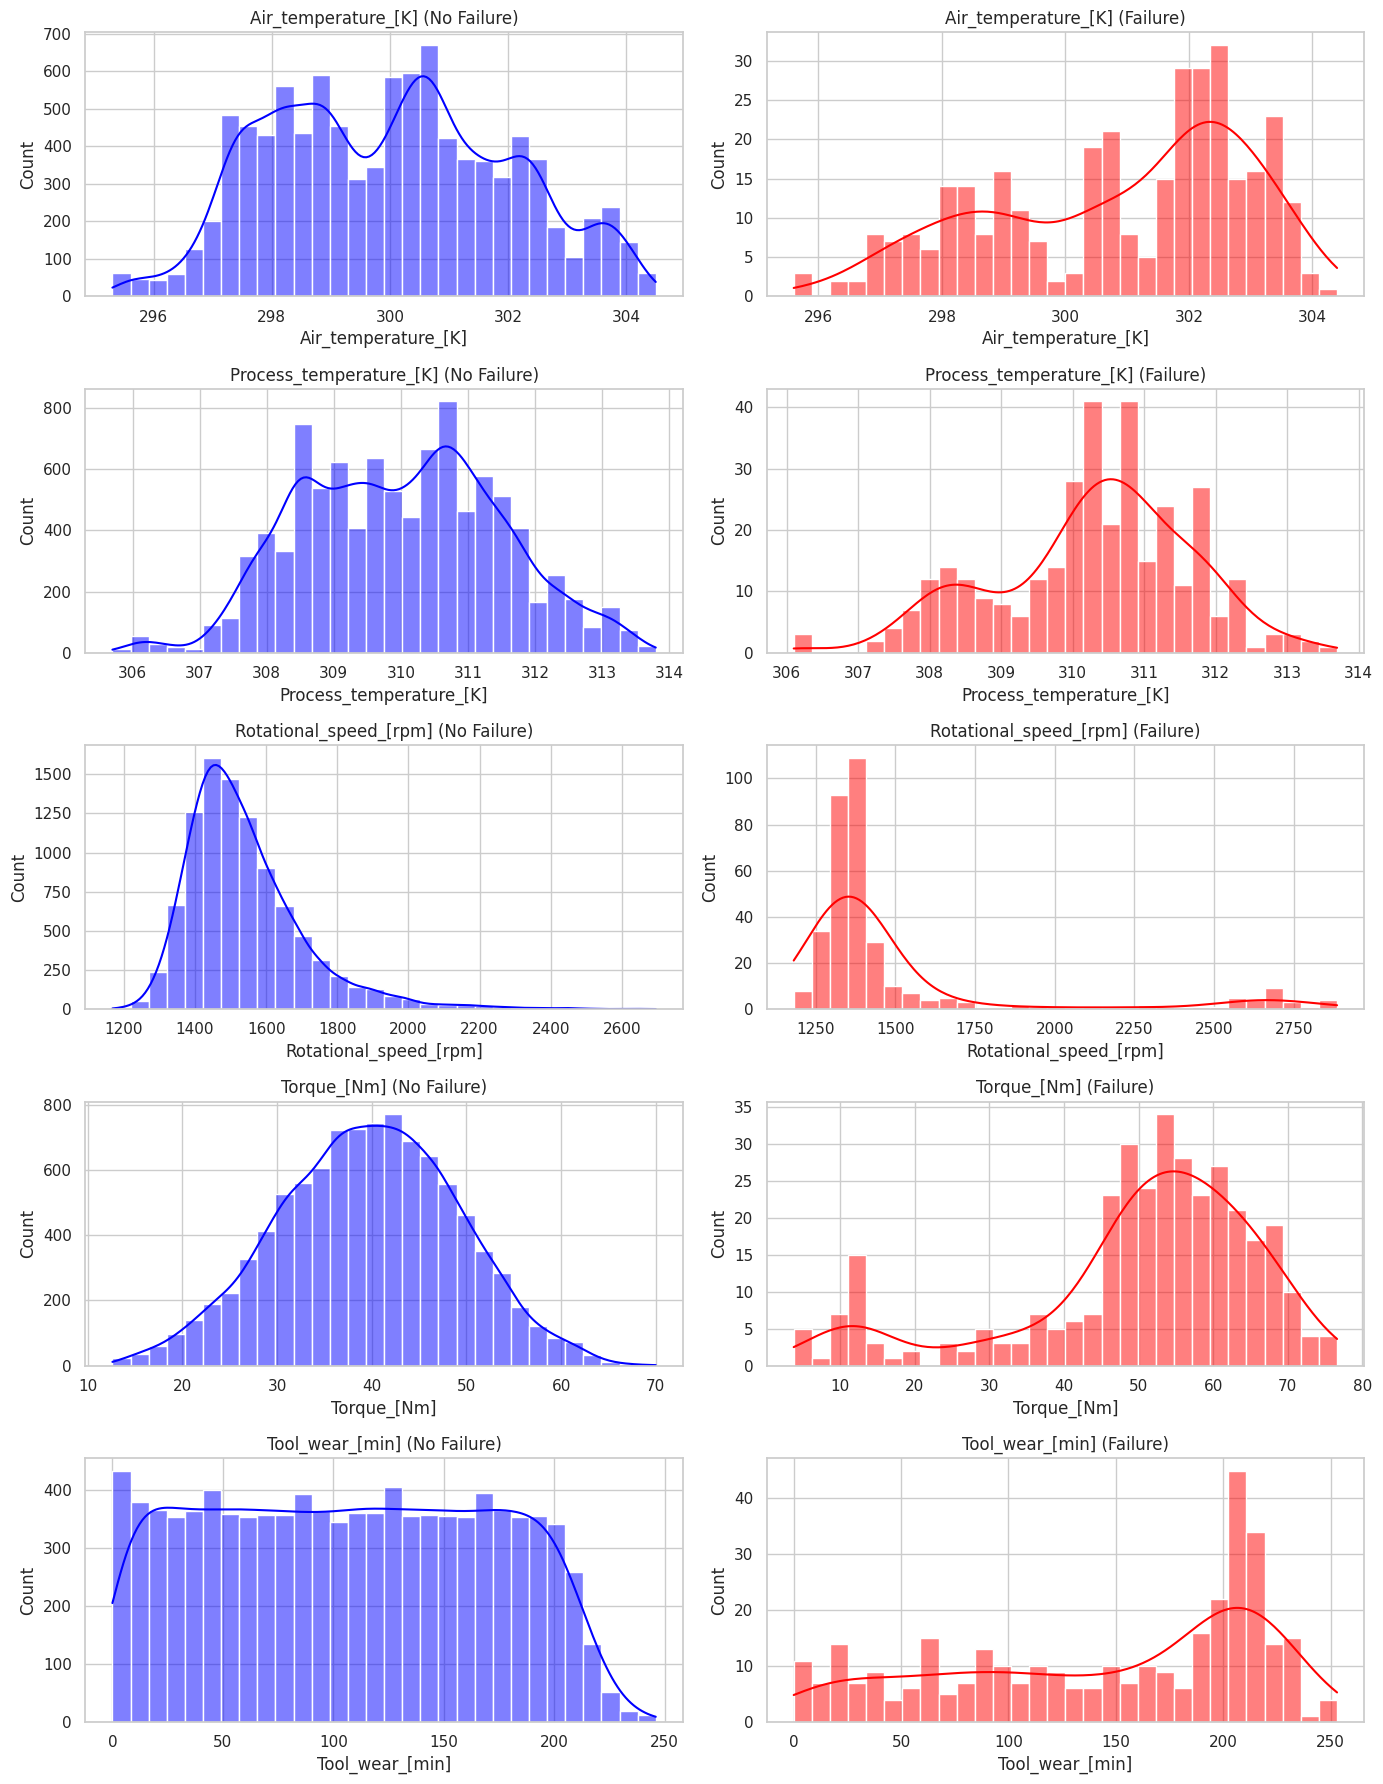

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

features = [
    'Air_temperature_[K]',
    'Process_temperature_[K]',
    'Rotational_speed_[rpm]',
    'Torque_[Nm]',
    'Tool_wear_[min]'
]

fig, axes = plt.subplots(len(features), 2, figsize=(14, 18))

for i, feature in enumerate(features):

    # No Failure (0)
    sns.histplot(
        df[df['Target'] == 0][feature],
        bins=30,
        kde=True,
        color='blue',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{feature} (No Failure)')

    # Failure (1)
    sns.histplot(
        df[df['Target'] == 1][feature],
        bins=30,
        kde=True,
        color='red',
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{feature} (Failure)')

plt.tight_layout()
plt.show()

In [ ]:
summary_stats = (
    df.groupby('Target')[features]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(2)
)

# Keep only the columns you want
summary_stats = summary_stats.loc[:, (slice(None), ['min', '25%', '50%', '75%', 'max', 'mean', 'std'])]

# Reshape
summary_stats = summary_stats.stack(level=0).reset_index()
summary_stats.columns = ['Target', 'Feature', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Mean', 'Std']

# Sort for readability
summary_stats = summary_stats.sort_values(['Feature', 'Target']).reset_index(drop=True)

summary_stats

/tmp/ipykernel_13702/41633648.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  summary_stats = summary_stats.stack(level=0).reset_index()


,Target,Feature,Min,Q1,Median,Q3,Max,Mean,Std
0,0,Air_temperature_[K],295.3,298.30,300.0,301.5,304.5,299.97,1.99
1,1,Air_temperature_[K],295.6,299.10,301.6,302.5,304.4,300.89,2.07
2,0,Process_temperature_[K],305.7,308.80,310.0,311.1,313.8,310.00,1.49
3,1,Process_temperature_[K],306.1,309.50,310.4,311.2,313.7,310.29,1.36
4,0,Rotational_speed_[rpm],1168.0,1429.00,1507.0,1615.0,2695.0,1540.26,167.39
5,1,Rotational_speed_[rpm],1181.0,1326.50,1365.0,1421.5,2886.0,1496.49,384.94
6,0,Tool_wear_[min],0.0,52.00,107.0,160.0,246.0,106.69,62.95
7,1,Tool_wear_[min],0.0,84.50,165.0,207.5,253.0,143.78,72.76
8,0,Torque_[Nm],12.6,33.10,39.9,46.3,70.0,39.63,9.47
9,1,Torque_[Nm],3.8,45.95,53.7,61.2,76.6,50.17,16.37


In [ ]:
#Training SVM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

X = df[features]
y = df['Target']

cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        tol=0.001,
        max_iter=-1,
        class_weight='balanced',
        probability=False
    ))
])

all_y_true = []
all_y_pred = []

for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)



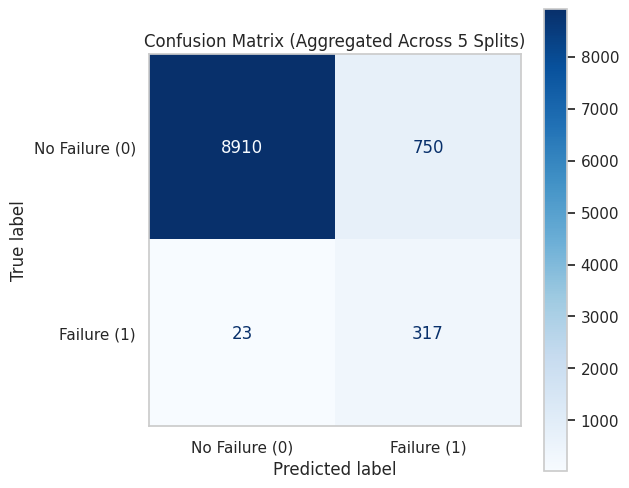

Total predictions: 10000


In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

all_y_true = []
all_y_pred = []

for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# Compute confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Failure (0)', 'Failure (1)']
)

disp.plot(cmap='Blues', ax=ax, colorbar=True)

plt.title("Confusion Matrix (Aggregated Across 5 Splits)")
plt.grid(False)
plt.show()

print("Total predictions:", np.sum(cm))

In [ ]:
#Additional metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", round(accuracy_score(all_y_true, all_y_pred), 3))
print("Precision:", round(precision_score(all_y_true, all_y_pred), 3))
print("Recall:", round(recall_score(all_y_true, all_y_pred), 3))
print("F1 Score:", round(f1_score(all_y_true, all_y_pred), 3))



Accuracy: 0.923
Precision: 0.297
Recall: 0.932
F1 Score: 0.451


In [ ]:
#Predictions

y_probs = svm_model.predict_proba(X_test)[:, 1]

# Show first 10 predictions
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted Probability (Failure)': y_probs
})

results.head(10)

,Actual,Predicted Probability (Failure)
0,0,0.133859
1,0,0.238269
2,0,0.297338
3,0,0.159622
4,0,0.111990
5,0,0.115931
6,0,0.060271
7,0,0.033590
8,0,0.053221
9,0,0.102328


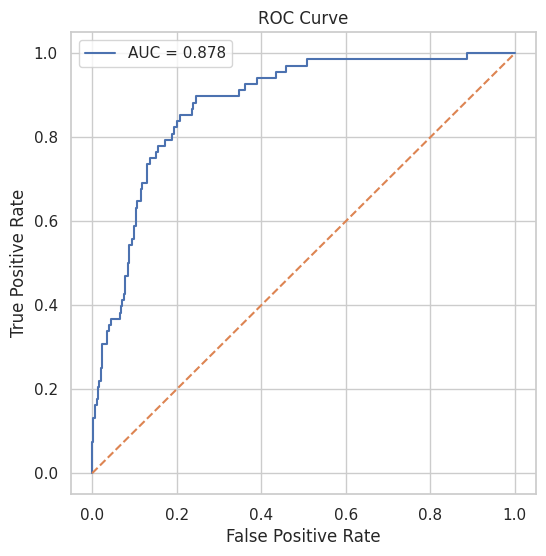

In [ ]:
#ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()